Dataset loaded (first 5 rows):
   SNo ObservationDate Province/State  Country/Region      Last Update  \
0    1      2020-01-22          Anhui  Mainland China  1/22/2020 17:00   
1    2      2020-01-22        Beijing  Mainland China  1/22/2020 17:00   
2    3      2020-01-22      Chongqing  Mainland China  1/22/2020 17:00   
3    4      2020-01-22         Fujian  Mainland China  1/22/2020 17:00   
4    5      2020-01-22          Gansu  Mainland China  1/22/2020 17:00   

   Confirmed  Deaths  Recovered  
0        1.0     0.0        0.0  
1       14.0     0.0        0.0  
2        6.0     0.0        0.0  
3        1.0     0.0        0.0  
4        0.0     0.0        0.0  

Using country: Mainland China (494 days of data)
                  SNo                                     Province/State  \
ObservationDate                                                            
2020-01-22        535  AnhuiBeijingChongqingFujianGansuGuangdongGuang...   
2020-01-23       1775  AnhuiBeijingChongqi

S,I,R
910145.0,547.0,28.0
909580.0,1082.0,58.0
909768.0,916.0,36.0
909282.0,1399.0,39.0
908609.0,2062.0,49.0


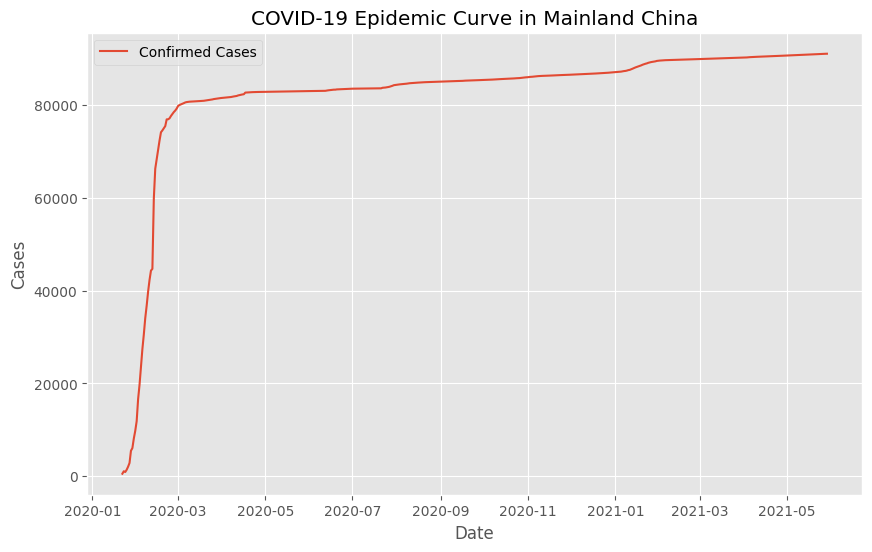

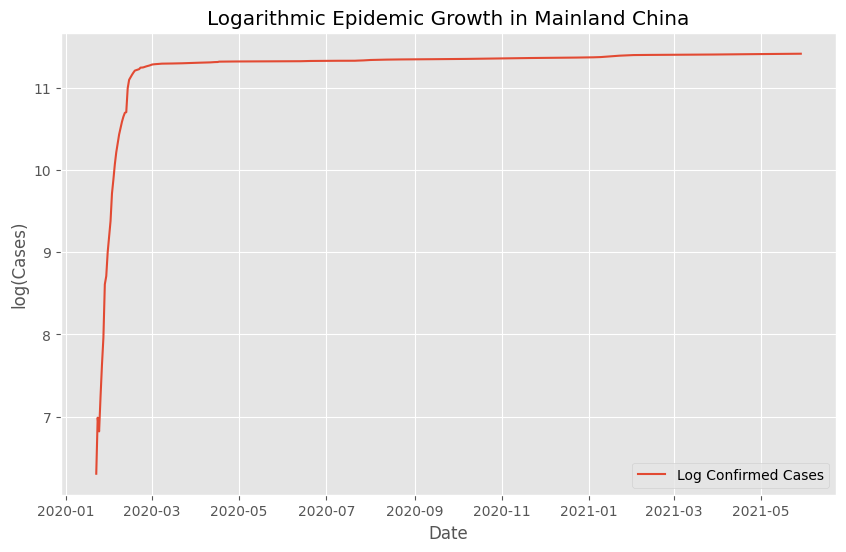

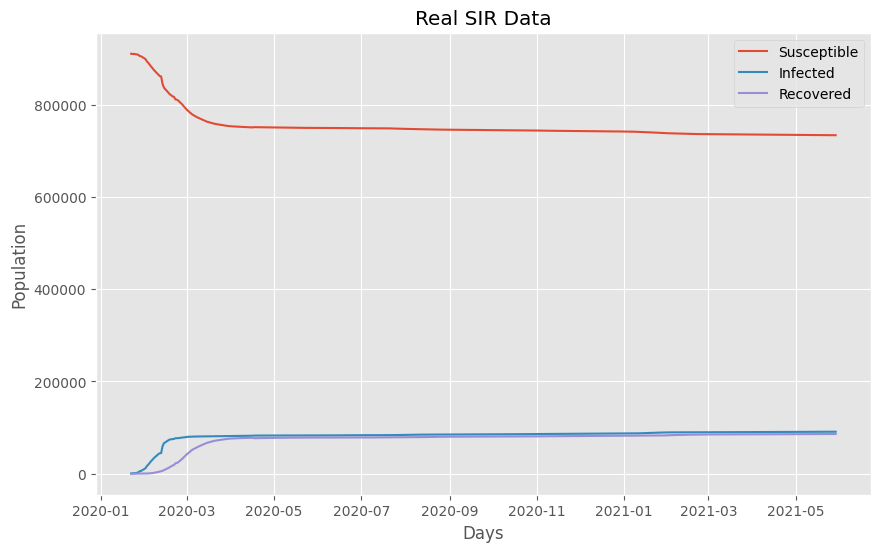


Estimated beta: 0.0452
Estimated gamma: 0.0243
Basic reproduction number R0: 1.86


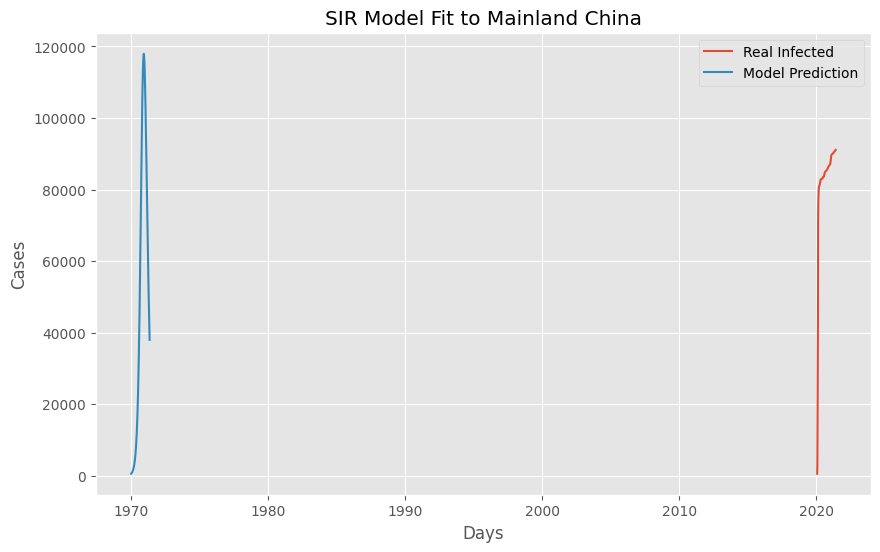

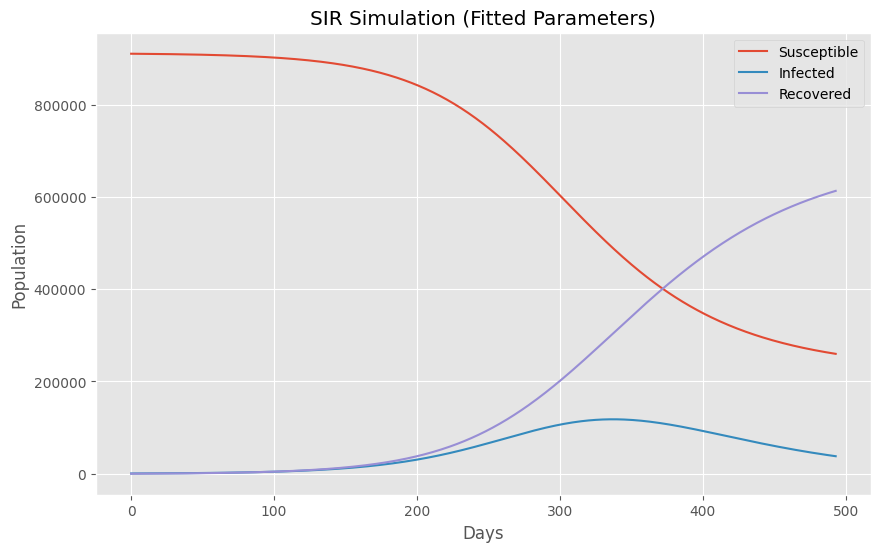

Day,Susceptible,Infected,Recovered
1,910145,547,28
2,910120,558,41
3,910094,570,55
4,910068,582,69
5,910041,594,83
6,910014,607,97
7,909987,620,112
8,909958,633,128
9,909929,646,143
10,909900,660,159



All done! Figures are saved in results/figures/


In [18]:
# ==========================================================
# EPIDEMIC MODELING PROJECT — SIR MODEL (Dynamic Country)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
import os
from IPython.display import display, HTML

plt.style.use("ggplot")
os.makedirs("../results/figures", exist_ok=True)

# ==========================================================
# 1. Load Kaggle dataset
# ==========================================================
data = pd.read_csv("../data/covid_19_data.csv")
data["ObservationDate"] = pd.to_datetime(data["ObservationDate"])
print("Dataset loaded (first 5 rows):")
print(data.head())

# ==========================================================
# 2. Automatically select first country in dataset
# ==========================================================
country = data["Country/Region"].iloc[0]
df = data[data["Country/Region"] == country]
df = df.groupby("ObservationDate").sum()
df = df[df["Confirmed"] > 0]  # remove zero cases

if len(df) < 2:
    raise ValueError(f"Not enough data for {country} to fit SIR model.")

print(f"\nUsing country: {country} ({len(df)} days of data)")
print(df.head())

# ==========================================================
# 3. Prepare SIR compartments
# ==========================================================
N = df["Confirmed"].max() * 10  # rough population estimate for demo
infected = df["Confirmed"].astype(float)
recovered = df["Recovered"].astype(float)
susceptible = N - infected - recovered

sir_df = pd.DataFrame({"S": susceptible, "I": infected, "R": recovered})
display(HTML(sir_df.head().to_html(index=False, border=1)))

# ==========================================================
# 4. Plot epidemic curve
# ==========================================================
plt.figure(figsize=(10,6))
plt.plot(df.index, infected, label="Confirmed Cases")
plt.title(f"COVID-19 Epidemic Curve in {country}")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.savefig("../results/figures/epidemic_curve.png")
plt.show()

# ==========================================================
# 5. Logarithmic growth
# ==========================================================
log_cases = np.log(infected)
plt.figure(figsize=(10,6))
plt.plot(df.index, log_cases, label="Log Confirmed Cases")
plt.title(f"Logarithmic Epidemic Growth in {country}")
plt.xlabel("Date")
plt.ylabel("log(Cases)")
plt.legend()
plt.savefig("../results/figures/log_growth.png")
plt.show()

# ==========================================================
# 6. Plot real SIR
# ==========================================================
plt.figure(figsize=(10,6))
plt.plot(sir_df["S"], label="Susceptible")
plt.plot(sir_df["I"], label="Infected")
plt.plot(sir_df["R"], label="Recovered")
plt.title("Real SIR Data")
plt.xlabel("Days")
plt.ylabel("Population")
plt.legend()
plt.savefig("../results/figures/sir_real_data.png")
plt.show()

# ==========================================================
# 7. Define SIR differential equations
# ==========================================================
def sir_model(y, t, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# ==========================================================
# 8. Initial conditions
# ==========================================================
I0 = infected.iloc[0]
R0 = recovered.iloc[0]
S0 = N - I0 - R0
initial_conditions = (S0, I0, R0)
t = np.arange(len(infected))

# ==========================================================
# 9. Fit beta and gamma
# ==========================================================
def sir_loss(params):
    beta, gamma = params
    solution = odeint(sir_model, initial_conditions, t, args=(beta, gamma))
    S_pred, I_pred, R_pred = solution.T
    return np.mean((I_pred - infected.values)**2)

initial_guess = [0.3, 0.1]
bounds = [(0.0001, 1), (0.0001, 1)]
result = minimize(sir_loss, initial_guess, bounds=bounds)
beta_opt, gamma_opt = result.x
R0 = beta_opt / gamma_opt

print(f"\nEstimated beta: {beta_opt:.4f}")
print(f"Estimated gamma: {gamma_opt:.4f}")
print(f"Basic reproduction number R0: {R0:.2f}")

# ==========================================================
# 10. Run SIR simulation
# ==========================================================
solution_opt = odeint(sir_model, initial_conditions, t, args=(beta_opt, gamma_opt))
S_opt, I_opt, R_opt = solution_opt.T

# ==========================================================
# 11. Plot model vs real infected
# ==========================================================
plt.figure(figsize=(10,6))
plt.plot(infected, label="Real Infected")
plt.plot(I_opt, label="Model Prediction")
plt.title(f"SIR Model Fit to {country}")
plt.xlabel("Days")
plt.ylabel("Cases")
plt.legend()
plt.savefig("../results/figures/model_vs_real.png")
plt.show()

# ==========================================================
# 12. Plot full SIR simulation
# ==========================================================
plt.figure(figsize=(10,6))
plt.plot(S_opt, label="Susceptible")
plt.plot(I_opt, label="Infected")
plt.plot(R_opt, label="Recovered")
plt.title("SIR Simulation (Fitted Parameters)")
plt.xlabel("Days")
plt.ylabel("Population")
plt.legend()
plt.savefig("../results/figures/sir_simulation_fitted.png")
plt.show()

# ==========================================================
# 13. Table of first few days
# ==========================================================
n_days = min(10, len(S_opt))
sir_table = pd.DataFrame({
    "Day": np.arange(1, n_days+1),
    "Susceptible": S_opt[:n_days].astype(int),
    "Infected": I_opt[:n_days].astype(int),
    "Recovered": R_opt[:n_days].astype(int)
})
display(HTML(sir_table.to_html(index=False, border=1)))

print("\nAll done! Figures are saved in results/figures/")